In [1]:
import logging
import numpy as np
from cache import load_words, load_patterns
from ranking import Ranker
from engine import Engine

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

words = load_words()
patterns = load_patterns()
ranker = Ranker(words, patterns)
engine = Engine(ranker)

INFO:cache:Loaded 14855 words of length 5 from resources/words.txt
INFO:cache:Loading pre-compiled cache resources/patterns.npy
INFO:ranking:Possibilities: 14855
INFO:ranking:Entropy: 13.86


In [2]:
solution = np.random.choice(words, 1)
engine.reset()
guesses = engine.simulate(solution[0])

INFO:game:Initialized game with solution fatso
INFO:engine:Using cached first guess tares
INFO:game:Guess 1: tares with result 🟨🟩⬛⬛🟨
INFO:ranking:Possibilities: 36
INFO:ranking:Entropy: 5.17
INFO:engine:Reduced reachable words by 14819
INFO:engine:Reduced entropy by 8.69
INFO:engine:Choosing highest entropy guess to prune state space.
INFO:game:Guess 2: shiny with result 🟨⬛⬛⬛⬛
INFO:ranking:Possibilities: 6
INFO:ranking:Entropy: 2.58
INFO:engine:Reduced reachable words by 30
INFO:engine:Reduced entropy by 2.58
INFO:engine:Choosing highest entropy guess to prune state space.
INFO:game:Guess 3: boult with result ⬛🟨⬛⬛🟨
INFO:ranking:Possibilities: 1
INFO:ranking:Entropy: 0.00
INFO:engine:Reduced reachable words by 5
INFO:engine:Reduced entropy by 2.58
INFO:engine:Reached endgame. Choosing likely solution to win.
INFO:game:Guess 4: fatso with result 🟩🟩🟩🟩🟩
INFO:game:Completed game in 4 turns


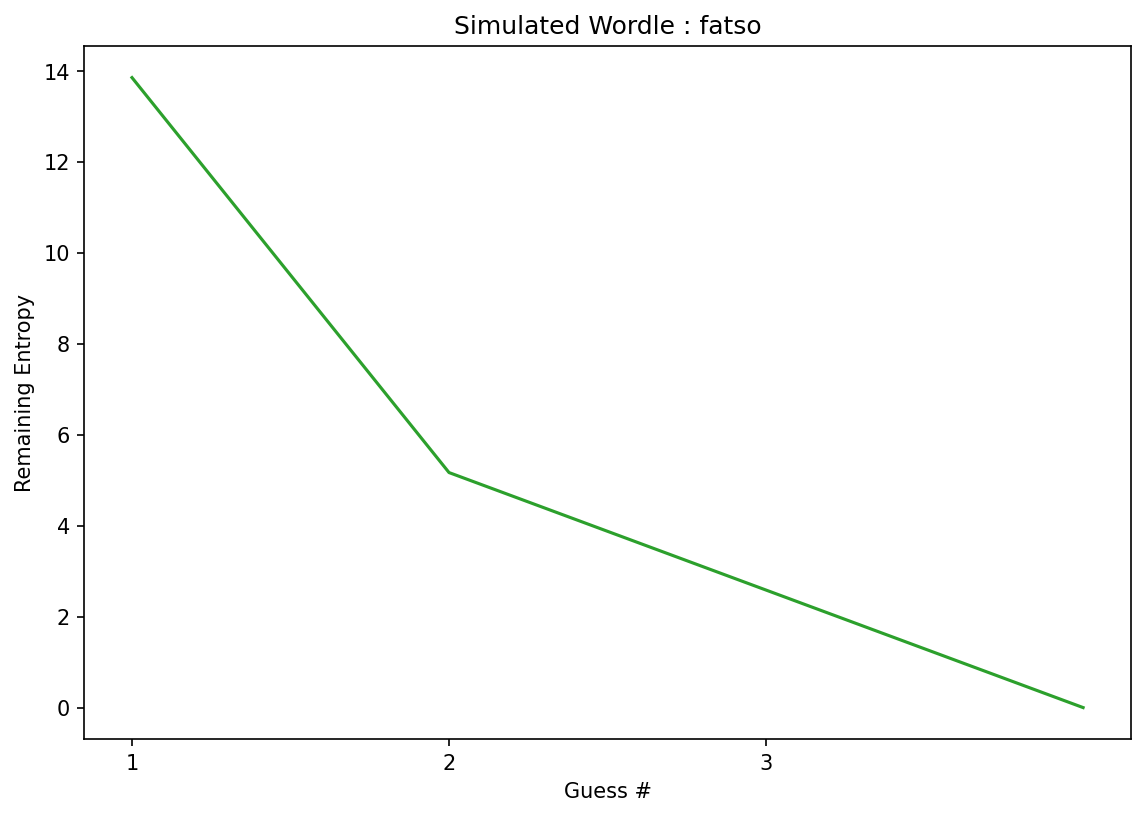

In [3]:
from matplotlib import pyplot as plt


plt.figure(figsize=(9, 6), dpi=150)
plt.title(f'Simulated Wordle : {solution[0]}')
plt.xlabel('Guess #')
plt.xticks(ticks=np.arange(len(engine.entropy_hist)))
plt.ylabel('Remaining Entropy')
guess_nums = np.arange(len(guesses))
plt.plot(guess_nums + 1, engine.entropy_hist, color='tab:green')
plt.show()